# Unit Root Tests
Implementation of the 3-step sequential ADF procedure and KPSS test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
# 1. Load the existing data
panel = pd.read_parquet('../data/intermediate/panel_monthly.parquet')
prices = pd.read_parquet('../data/intermediate/prices_raw.parquet')

# Build Momentum (12-month trailing return)
prices['date'] = pd.to_datetime(prices['date'])
prices['month'] = prices['date'].dt.to_period('M')
monthly_prices = prices.groupby(['ticker', 'month'])['close'].last().reset_index()
monthly_prices['mom_12m'] = monthly_prices.groupby('ticker')['close'].shift(1) / monthly_prices.groupby('ticker')['close'].shift(12) - 1

panel['month'] = pd.to_datetime(panel['date']).dt.to_period('M')
df = pd.merge(panel, monthly_prices[['ticker', 'month', 'mom_12m']], on=['ticker', 'month'], how='left')

# Proxy Size as Log Dollar Volume
df['Size'] = np.log(df['Avg_Volume'])

# Winsorize Amihud (Liquidity) like in DiD estimation
p01, p99 = df['Amihud'].quantile(0.01), df['Amihud'].quantile(0.99)
df['Amihud'] = df['Amihud'].clip(lower=p01, upper=p99)

# Aggregate cross-sectionally to obtain the market-wide time series for each variable
ts = df.groupby('date').agg({
    'Synchronicity': 'mean',
    'Size': 'mean',
    'Amihud': 'mean',
    'mom_12m': 'mean'
}).dropna()

ts.rename(columns={'Amihud': 'Liquidity', 'mom_12m': 'Momentum'}, inplace=True)
print("Time series shape:", ts.shape)
ts.head()


Time series shape: (146, 4)


,Synchronicity,Size,Liquidity,Momentum
date,,,,
2014-01-01,-2.196359,12.219072,0.259722,0.315943
2014-02-01,-2.734778,12.243888,0.277976,0.288172
2014-03-01,-1.312951,12.277082,0.288127,0.361828
2014-04-01,-2.029316,12.175904,0.291881,0.344053
2014-05-01,-2.927387,12.135157,0.320142,0.288997


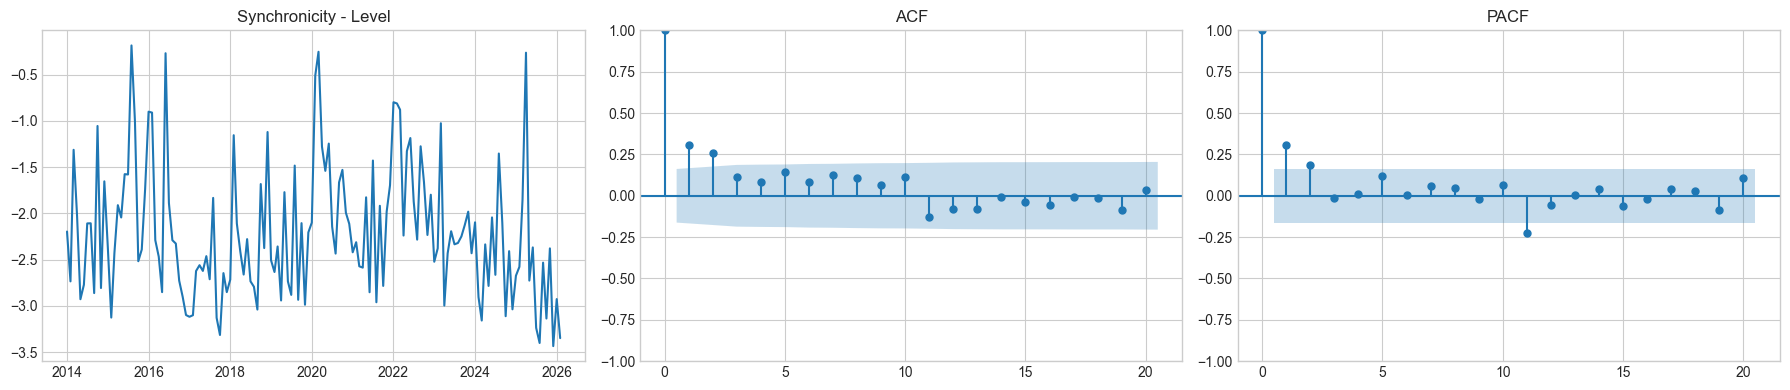

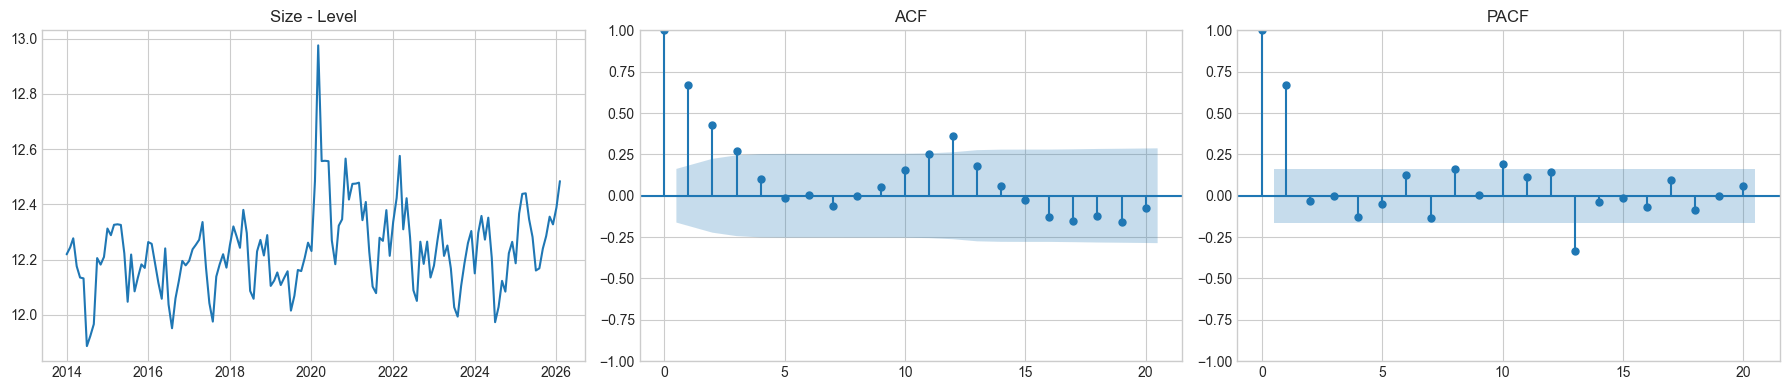

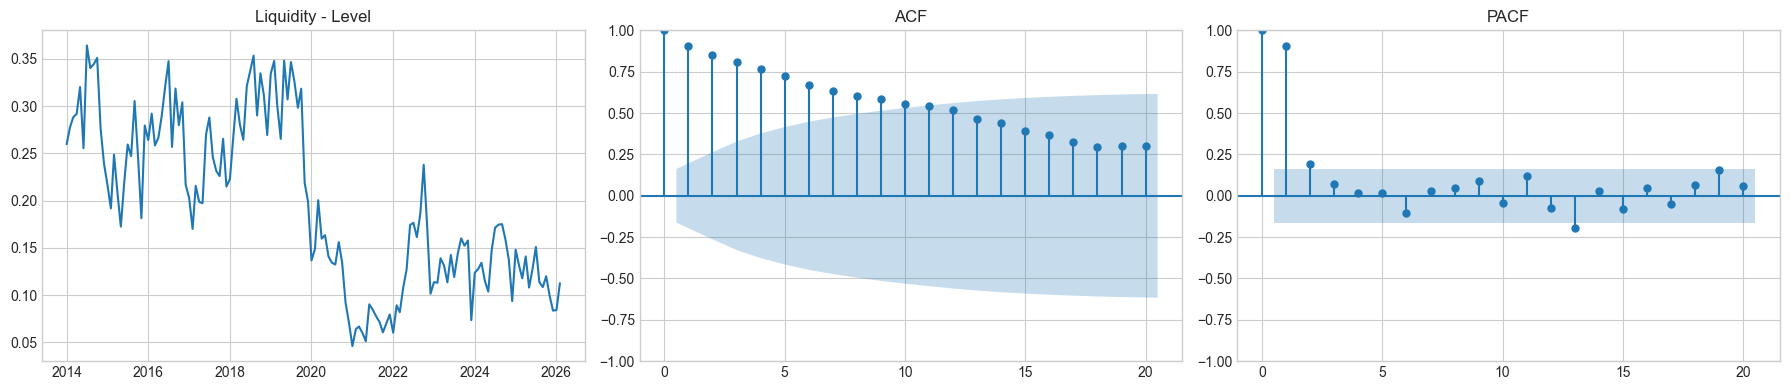

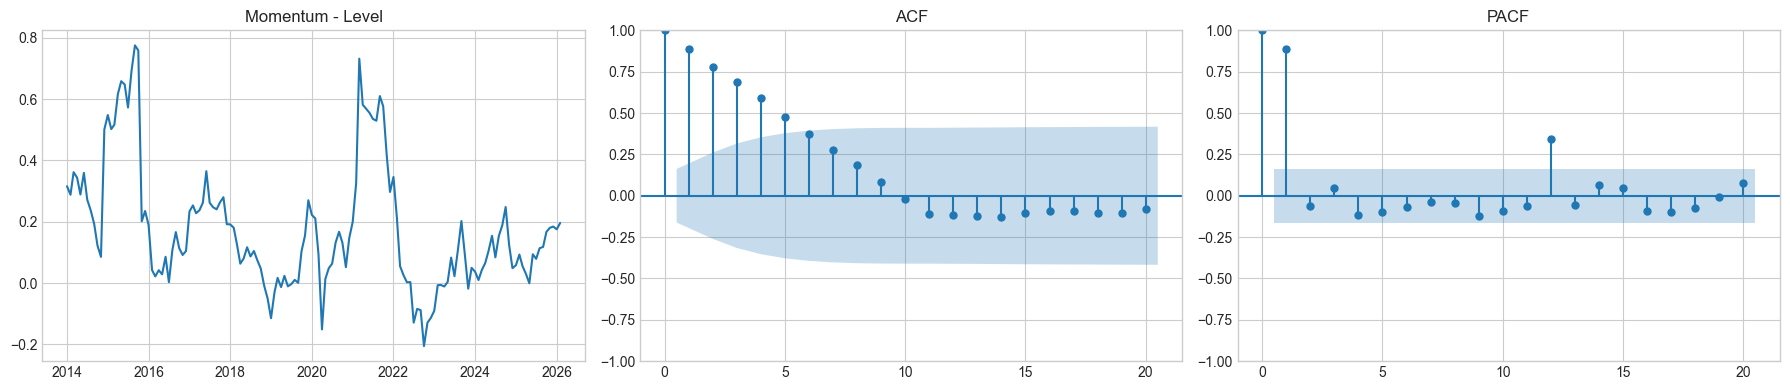

In [3]:
# 2. Sequential ADF Procedure & Plots

def run_sequential_adf(series, name, diff=False):
    if diff:
        series = series.diff().dropna()
        prefix = 'Δ '
    else:
        prefix = ''
    
    # Step 1: Trend + Constant
    res_ct = adfuller(series, regression='ct', autolag='AIC')
    if res_ct[1] < 0.05:
        return {'Variable': f"{prefix}{name}", 'Step': '1 (ct)', 'ADF Stat': res_ct[0], 'p-value': res_ct[1], 'CV 5%': res_ct[4]['5%'], 'Verdict': 'I(0)'}
    
    # Step 2: Constant only
    res_c = adfuller(series, regression='c', autolag='AIC')
    if res_c[1] < 0.05:
        return {'Variable': f"{prefix}{name}", 'Step': '2 (c)', 'ADF Stat': res_c[0], 'p-value': res_c[1], 'CV 5%': res_c[4]['5%'], 'Verdict': 'I(0)'}
        
    # Step 3: No Constant
    res_nc = adfuller(series, regression='n', autolag='AIC')
    if res_nc[1] < 0.05:
        return {'Variable': f"{prefix}{name}", 'Step': '3 (nc)', 'ADF Stat': res_nc[0], 'p-value': res_nc[1], 'CV 5%': res_nc[4]['5%'], 'Verdict': 'I(0)'}
        
    return {'Variable': f"{prefix}{name}", 'Step': '3 (nc)', 'ADF Stat': res_nc[0], 'p-value': res_nc[1], 'CV 5%': res_nc[4]['5%'], 'Verdict': 'I(1)'}

def run_kpss(series):
    # KPSS tests null of stationary vs alternative of unit root
    # So p-value < 0.05 means we REJECT stationarity -> I(1)
    res = kpss(series, regression='c', nlags='auto') # level stationarity
    if res[1] < 0.05:
        return 'I(1) (Reject H0)'
    return 'I(0) (Fail to reject H0)'

results = []

out_dir = Path('../figures/unit_root')
out_dir.mkdir(parents=True, exist_ok=True)

for col in ts.columns:
    series = ts[col]
    
    # Plot Level & ACF/PACF
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(series)
    axes[0].set_title(f'{col} - Level')
    plot_acf(series, ax=axes[1], lags=20, title='ACF')
    plot_pacf(series, ax=axes[2], lags=20, title='PACF')
    plt.tight_layout()
    plt.savefig(out_dir / f"{col}_level_acf_pacf.png")
    plt.show()
    
    # ADF
    res = run_sequential_adf(series, col)
    # KPSS
    res['KPSS Verdict'] = run_kpss(series)
    results.append(res)
    
    # If I(1), diff
    if res['Verdict'] == 'I(1)':
        res_diff = run_sequential_adf(series, col, diff=True)
        res_diff['KPSS Verdict'] = run_kpss(series.diff().dropna())
        results.append(res_diff)

summary_df = pd.DataFrame(results)


In [6]:
# 4. Clean Summary Table
summary_df


,Variable,Step,ADF Stat,p-value,CV 5%,Verdict,KPSS Verdict
0,Synchronicity,1 (ct),-5.697435,9.268964e-06,-3.441430,I(0),I(0) (Fail to reject H0)
1,Size,3 (nc),0.434927,8.095084e-01,-1.943197,I(1),I(0) (Fail to reject H0)
2,Δ Size,1 (ct),-4.251404,3.739215e-03,-3.444031,I(0),I(0) (Fail to reject H0)
3,Liquidity,3 (nc),-1.235185,1.990740e-01,-1.943032,I(1),I(1) (Reject H0)
4,Δ Liquidity,1 (ct),-10.606819,1.298730e-16,-3.441649,I(0),I(0) (Fail to reject H0)
5,Momentum,3 (nc),-1.948781,4.902420e-02,-1.943179,I(0),I(0) (Fail to reject H0)
